# Phase 4 — Ensemble Methods & Unsupervised Learning

**Goal:** Improve on Phase 3's classifiers with a Random Forest, then discover structure in the data without labels using K-Means clustering and PCA.

**Libraries:** `pandas`, `scikit-learn`, `matplotlib`

**Input:** `../star_dataset_clean.csv`

**Models:** Random Forest, K-Means, PCA

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, adjusted_rand_score

In [9]:
df = pd.read_csv("../star_dataset_clean.csv")

feature_cols = ['Distance (ly)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Temperature (K)']
X = df[feature_cols]
y = df['Spectral Class']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Training shape:", X_train_scaled.shape)
print("Test shape:    ", X_test_scaled.shape)
print("Classes:       ", label_encoder.classes_)

Training shape: (23, 4)
Test shape:     (6, 4)
Classes:        ['A0V' 'A1V' 'A2Ia' 'A3V' 'A7V' 'A9II' 'B0.5IV' 'B0Ia' 'B1III' 'B1III-IV'
 'B2III' 'B6Vep' 'B7V' 'B8Ia' 'F5IV-V' 'F7Ib' 'G2V' 'G8III' 'K1.5III'
 'K1V' 'K5III' 'M1.5Iab' 'M2.1V' 'M2Iab' 'M3.5V' 'M4Ve' 'M6V' 'M7IIIe']


c:\Users\ajgeb\Desktop\Tech & Coding\Coding_Project\astronomy_data_analysis\.venv\Lib\site-packages\sklearn\ensemble\_forest.py:811: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Users\ajgeb\Desktop\Tech & Coding\Coding_Project\astronomy_data_analysis\.venv\Lib\site-packages\sklearn\tree\_classes.py:289: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Users\ajgeb\Desktop\Tech & Coding\Coding_Project\astronomy_data_analysis\.venv\Lib\site-packages\sklearn\tree\_classes.py:289: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Users\ajgeb\Desktop\Te

Random Forest Classification Report:
              precision    recall  f1-score   support

         A0V       0.00      0.00      0.00       1.0
         A1V       0.00      0.00      0.00       0.0
      B0.5IV       0.00      0.00      0.00       0.0
        B0Ia       0.00      0.00      0.00       0.0
       B1III       0.00      0.00      0.00       1.0
    B1III-IV       0.00      0.00      0.00       0.0
       B2III       0.00      0.00      0.00       1.0
        B8Ia       0.00      0.00      0.00       1.0
       G8III       0.00      0.00      0.00       1.0
     K1.5III       0.00      0.00      0.00       0.0
         K1V       0.00      0.00      0.00       0.0
        M4Ve       0.00      0.00      0.00       1.0

    accuracy                           0.00       6.0
   macro avg       0.00      0.00      0.00       6.0
weighted avg       0.00      0.00      0.00       6.0



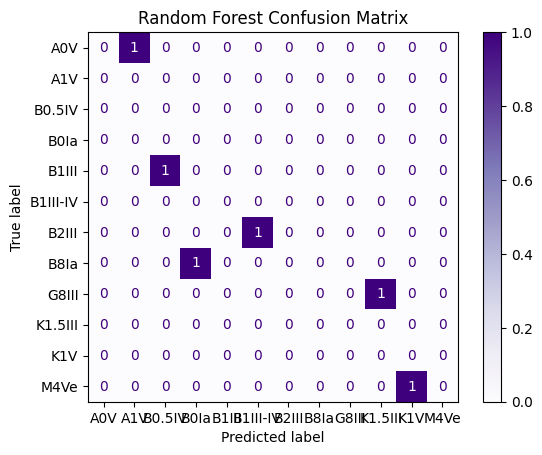

Random Forest Test Accuracy: 0.0000


In [10]:
# --- Random Forest Classifier ---
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

present_labels = sorted(set(y_test) | set(y_pred_rf))
present_names  = label_encoder.inverse_transform(present_labels)

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, labels=present_labels, target_names=present_names))

cm_rf = confusion_matrix(y_test, y_pred_rf, labels=present_labels)
ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=present_names).plot(cmap=plt.cm.Purples)
plt.title("Random Forest Confusion Matrix")
plt.show()

rf_accuracy = (y_test == y_pred_rf).mean()
print(f"Random Forest Test Accuracy: {rf_accuracy:.4f}")

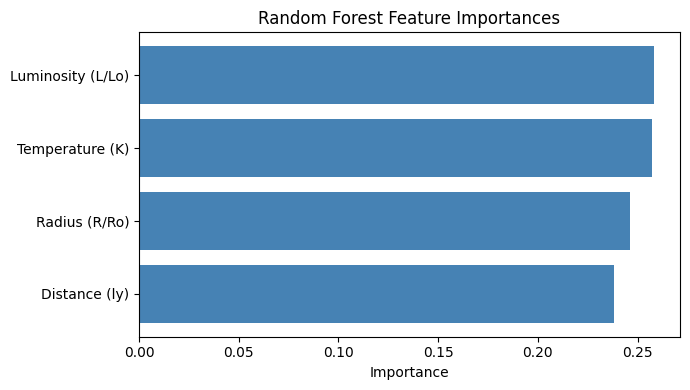

In [11]:
# --- Feature Importances ---
importances = rf.feature_importances_
sorted_idx  = np.argsort(importances)

plt.figure(figsize=(7, 4))
plt.barh(np.array(feature_cols)[sorted_idx], importances[sorted_idx], color='steelblue')
plt.xlabel("Importance")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()

In [12]:
# --- K-Means Clustering (k=7 for 7 broad spectral types) ---
# Scale all 29 stars (not just the train split) for clustering
X_all_scaled = scaler.transform(X)

kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_all_scaled)

ari = adjusted_rand_score(y_encoded, cluster_labels)
print(f"Adjusted Rand Index: {ari:.4f}")
print("(1.0 = perfect match with true labels, 0 = random, <0 = worse than random)")

Adjusted Rand Index: 0.0063
(1.0 = perfect match with true labels, 0 = random, <0 = worse than random)


PC1 explains 51.0% of variance
PC2 explains 33.5% of variance


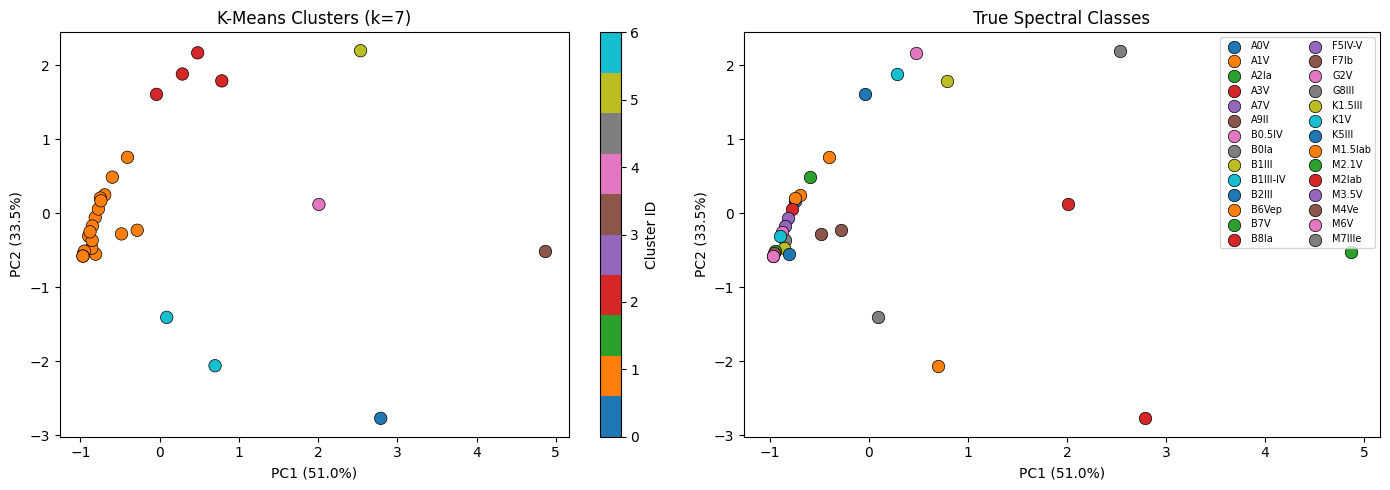

In [13]:
# --- PCA: 2D projection, K-Means clusters vs true classes ---
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_all_scaled)

var_explained = pca.explained_variance_ratio_
print(f"PC1 explains {var_explained[0]*100:.1f}% of variance")
print(f"PC2 explains {var_explained[1]*100:.1f}% of variance")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: K-Means clusters
scatter = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels, cmap='tab10', s=80, edgecolors='k', linewidths=0.5)
axes[0].set_title("K-Means Clusters (k=7)")
axes[0].set_xlabel(f"PC1 ({var_explained[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({var_explained[1]*100:.1f}%)")
plt.colorbar(scatter, ax=axes[0], label="Cluster ID")

# Right: True spectral classes
colors = plt.cm.tab10.colors
true_class_labels = label_encoder.inverse_transform(y_encoded)
unique_classes = label_encoder.classes_
for i, cls in enumerate(unique_classes):
    mask = true_class_labels == cls
    if mask.any():
        axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1], color=colors[i % 10],
                        label=cls, s=80, edgecolors='k', linewidths=0.5)
axes[1].set_title("True Spectral Classes")
axes[1].set_xlabel(f"PC1 ({var_explained[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({var_explained[1]*100:.1f}%)")
axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig("../figures/pca_clusters.png", dpi=150)
plt.show()